In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv("emotiv_no_ohe.csv")

# One-hot encode the 'Command' column
ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
ohe_encoded = ohe.fit_transform(df[['Command']])
df_ohe = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(['Command']))
df = df.drop(columns=['Command'])
df = pd.concat([df, df_ohe], axis=1)

# Sequence generator
def df_to_X_y(df, window_size=5):
    df_as_np = df.to_numpy()
    X, y = [], []
    for i in range(len(df_as_np) - window_size):
        X.append(df_as_np[i:i+window_size])
        y.append(df_as_np[i+window_size])  # Still entire row for now
    return np.array(X), np.array(y)

WINDOW_SIZE = 5
X, y = df_to_X_y(df, WINDOW_SIZE)

# You can target a specific label column for y, e.g., the first one if needed:
y = y[:, 0]  # adjust to fit your actual prediction target

# Train-test split
X_train, y_train = X[:800], y[:800]
X_val, y_val = X[800:900], y[800:900]
X_test, y_test = X[900:], y[900:]

# Model
model = Sequential()
model.add(InputLayer((WINDOW_SIZE, X.shape[2])))
model.add(LSTM(64))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(loss=MeanSquaredError(), optimizer=Adam(learning_rate=0.001), metrics=[RootMeanSquaredError()])
early_stopping = EarlyStopping(patience=10, restore_best_weights=True)
cp = ModelCheckpoint('model1.keras', save_best_only=True)

# Train
history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, callbacks=[cp, early_stopping])

# Evaluate
y_pred_test = model.predict(X_test)
y_pred_test_rounded = np.round(y_pred_test).astype(int)
y_test_rounded = np.round(y_test).astype(int)

accuracy = accuracy_score(y_test_rounded, y_pred_test_rounded)
print("Test accuracy:", accuracy)

# Plotting
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['root_mean_squared_error'], label='Training RMSE')
plt.plot(history.history['val_root_mean_squared_error'], label='Validation RMSE')
plt.title('Root Mean Squared Error (RMSE)')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.legend()

plt.tight_layout()
plt.show()

print("Model input shape:", model.input_shape)


Epoch 1/50


c:\Users\alecx\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5522 - loss: 1.0133 - val_accuracy: 0.6496 - val_loss: 0.7926
Epoch 2/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6563 - loss: 0.7749 - val_accuracy: 0.6819 - val_loss: 0.6402
Epoch 3/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6787 - loss: 0.6378 - val_accuracy: 0.7008 - val_loss: 0.5865
Epoch 4/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7436 - loss: 0.5636 - val_accuracy: 0.7224 - val_loss: 0.5601
Epoch 5/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7268 - loss: 0.5341 - val_accuracy: 0.7305 - val_loss: 0.5540
Epoch 6/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7831 - loss: 0.4663 - val_accuracy: 0.7574 - val_loss: 0.5268
Epoch 7/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7864 - loss: 0.4648 - val_accuracy: 0.7736 - val_loss: 0.5024
Epoch 8/50
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8244 - loss: 0.4073 - val_accuracy: 0.7547 - val_loss: 0.5045
E

In [34]:
# Load the best model
model.load_weights('model.keras')

# Make predictions and compare to actual commands
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

# Print each prediction with the actual command
num_comparisons = min(50, len(predicted_classes))  # Ensure we have at least 10 comparisons or as many as available
for i in range(num_comparisons):
    print(f"Sample {i + 1}: Predicted Command = {predicted_classes[i]}, Actual Command = {true_classes[i]}")

# Calculate and print overall accuracy
accuracy = np.mean(predicted_classes == true_classes)
print("\nOverall Prediction Accuracy: {:.2f}%".format(accuracy * 100))

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
Sample 1: Predicted Command = 0, Actual Command = 0
Sample 2: Predicted Command = 2, Actual Command = 2
Sample 3: Predicted Command = 0, Actual Command = 0
Sample 4: Predicted Command = 0, Actual Command = 0
Sample 5: Predicted Command = 0, Actual Command = 1
Sample 6: Predicted Command = 0, Actual Command = 0
Sample 7: Predicted Command = 0, Actual Command = 0
Sample 8: Predicted Command = 0, Actual Command = 0
Sample 9: Predicted Command = 0, Actual Command = 0
Sample 10: Predicted Command = 1, Actual Command = 1
Sample 11: Predicted Command = 0, Actual Command = 0
Sample 12: Predicted Command = 0, Actual Command = 0
Sample 13: Predicted Command = 2, Actual Command = 2
Sample 14: Predicted Command = 1, Actual Command = 1
Sample 15: Predicted Command = 0, Actual Command = 2
Sample 16: Predicted Command = 0, Actual Command = 0
Sample 17: Predicted Command = 0, Actual Command = 0
Sample 18: Predicted Command = 0, Actual Command = 0
Sample 19: Pred

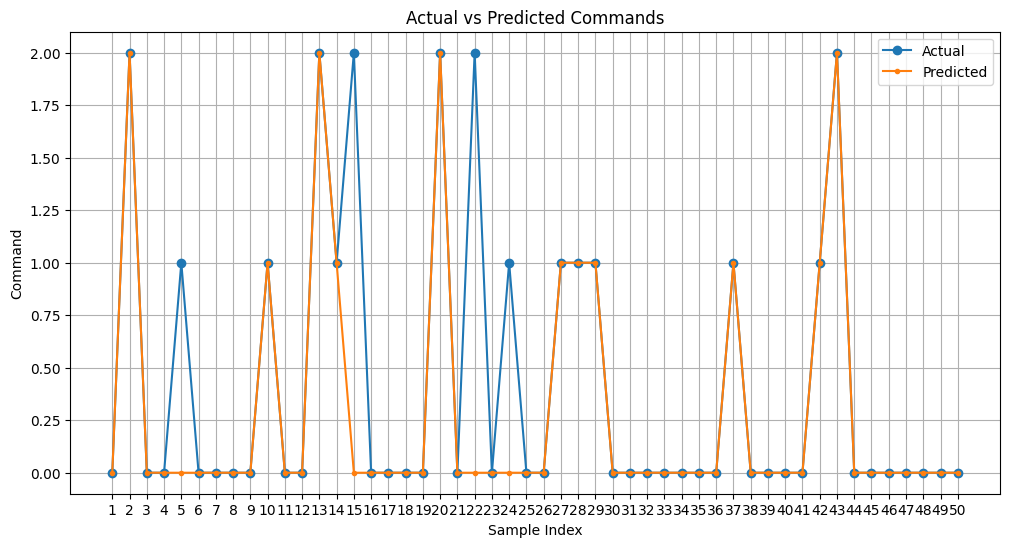

In [35]:
import matplotlib.pyplot as plt

# Create a figure
plt.figure(figsize=(12, 6))

# Plot actual vs predicted
plt.plot(true_classes[:num_comparisons], label='Actual', marker='o')
plt.plot(predicted_classes[:num_comparisons], label='Predicted', marker='.')

# Add labels and title
plt.title('Actual vs Predicted Commands')
plt.xlabel('Sample Index')
plt.ylabel('Command')
plt.xticks(ticks=np.arange(num_comparisons), labels=np.arange(1, num_comparisons + 1))
plt.legend()
plt.grid()

# Show the plot
plt.show()


In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[216  12   2]
 [ 20  80   0]
 [  4   0  37]]


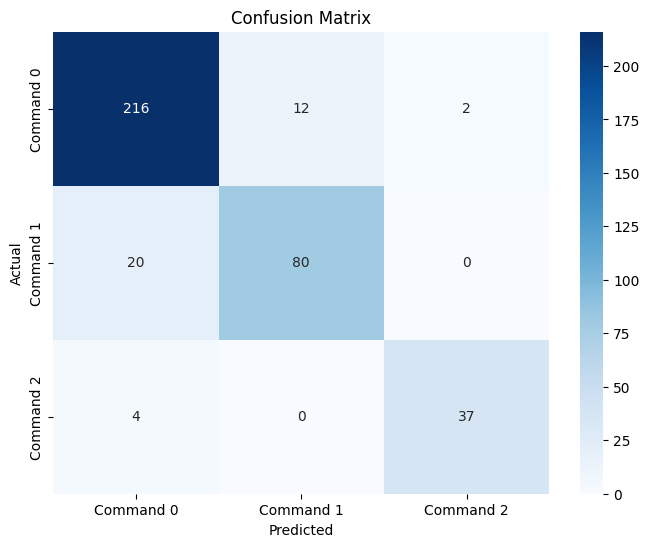

In [37]:
# Set up the confusion matrix plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Command 0', 'Command 1', 'Command 2'],
            yticklabels=['Command 0', 'Command 1', 'Command 2'])

# Add labels and title
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.show()


In [39]:
loaded_model = load_model('model.keras')

print(loaded_model.input_shape)

(None, 5, 25)
